# Clustering analysis, S2W8A2 Stage 2

WILDA Team 4, customer churn analysis. Owner: Ramesh Kunwar.

This notebook produces the three clustering deliverables:

1. The number of clusters, chosen with the elbow method and supported by charts
2. A trained K-Means model, with the code that trained it
3. The clusters visualised and named, with the insight and action for each segment

The code is in [`clustering_analysis.py`](clustering_analysis.py). This notebook imports
that script and runs it, so the notebook and the command line write identical files from
one copy of the code. To run the pipeline without Jupyter:

```bash
python Clustering_Analysis/clustering_analysis.py
```

The script reads `Data_Preparation/train_set.csv` and `Data_Preparation/test_set.csv`, so
run `Data_Preparation/data_preparation.ipynb` first if those files are missing.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Works whether the notebook is started from the repository root or from
# Clustering_Analysis/, so the import below always resolves.
HERE = Path.cwd() if Path.cwd().name == "Clustering_Analysis" else Path.cwd() / "Clustering_Analysis"
sys.path.insert(0, str(HERE))

from clustering_analysis import (K_RANGE, N_INIT, OPTIMAL_K, OUT_DIR, PLOTS,
                                 RANDOM_STATE, TARGET_COL, run_pipeline)

print(f"Prepared data: {(OUT_DIR.parent / 'Data_Preparation')}")
print(f"Output folder: {OUT_DIR}")
print(f"Target held back: {TARGET_COL} | k tested: {K_RANGE.start} to {K_RANGE.stop - 1}")
print(f"Chosen k: {OPTIMAL_K} | n_init: {N_INIT} | random_state: {RANDOM_STATE}")

Prepared data: C:\ACS_Will_Program\Data_Preparation
Output folder: C:\ACS_Will_Program\Clustering_Analysis
Target held back: Churn | k tested: 1 to 10
Chosen k: 4 | n_init: 10 | random_state: 42


## 1. Run the pipeline

`run_pipeline()` runs every step in order. It loads the prepared sets, searches k from 1
to 10, trains the final model, profiles and names the segments, writes the output files
and draws the five charts. The log below shows what each step did.

The model is fitted on the 5,634 training rows only. The 1,409 test rows are assigned
afterwards with `model.predict`, which puts each one with its nearest existing centre
without moving that centre. `Churn` is never a clustering feature, because Stage 3
predicts it.

In [2]:
model, metrics, profile, assignments = run_pipeline()

Training set: 5634 rows, churn rate 26.54%
Testing set:  1409 rows, churn rate 26.54%
Clustering features (10): ['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'MonthlyCharges', 'Contract_One_year', 'Contract_Two_year']
'Churn' held back, used only to score the finished segments.

--- Searching k = 1 to 10 ---


C:\ACS_Will_Program\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


  k= 1  inertia   19,845.66  drop     n/a  silhouette    n/a


  k= 2  inertia   14,844.21  drop  25.20%  silhouette 0.2274


  k= 3  inertia   12,178.36  drop  17.96%  silhouette 0.2116


...

Saved chart: Clustering_Analysis\cluster_visualisations\elbow_method.png


Saved chart: Clustering_Analysis\cluster_visualisations\segments_tenure_vs_charges.png


Saved chart: Clustering_Analysis\cluster_visualisations\segments_pca.png


Saved chart: Clustering_Analysis\cluster_visualisations\churn_rate_by_segment.png


Saved chart: Clustering_Analysis\cluster_visualisations\segment_profiles.png


=== Clustering Analysis Complete ===
Chosen k: 4 (elbow method)
Inertia at k=4: 10,700.86
Silhouette at k=4: 0.2031
Overall training churn rate: 26.54%

Segment                      Size   Share   Churn    Tenure    Charge
New high spenders           1,775   31.5%   48.7%    14.9 mo     81.1
New low spenders            1,381   24.5%   24.8%    10.5 mo     32.1
Long-term high spenders     1,512   26.8%   16.1%    58.7 mo     93.8
Long-term low spenders        966   17.1%    4.8%    54.5 mo     34.8


## 2. How we chose k

Inertia is the within-cluster sum of squares. It adds up the squared distance from every
customer to the centre of its own cluster, and it always falls as k rises, so its value
alone cannot choose k. The elbow method reads the size of each fall instead. The table
below reports that fall as a percentage, so the reading is a number rather than a
judgement about the shape of a line.

In [3]:
metrics.style.format({
    "inertia": "{:,.2f}",
    "inertia_drop_pct": "{:.2f}%",
    "silhouette": "{:.4f}",
}, na_rep="").hide(axis="index")

k,inertia,inertia_drop_pct,silhouette
1,"19,845.66",,
2,"14,844.21",25.20%,0.2274
3,"12,178.36",17.96%,0.2116
4,"10,700.86",12.13%,0.2031
5,"10,152.73",5.12%,0.1801
6,"9,712.96",4.33%,0.1565
7,"9,382.54",3.40%,0.1397
8,"9,011.45",3.96%,0.1393
9,"8,826.27",2.05%,0.1328
10,"8,594.34",2.63%,0.1287


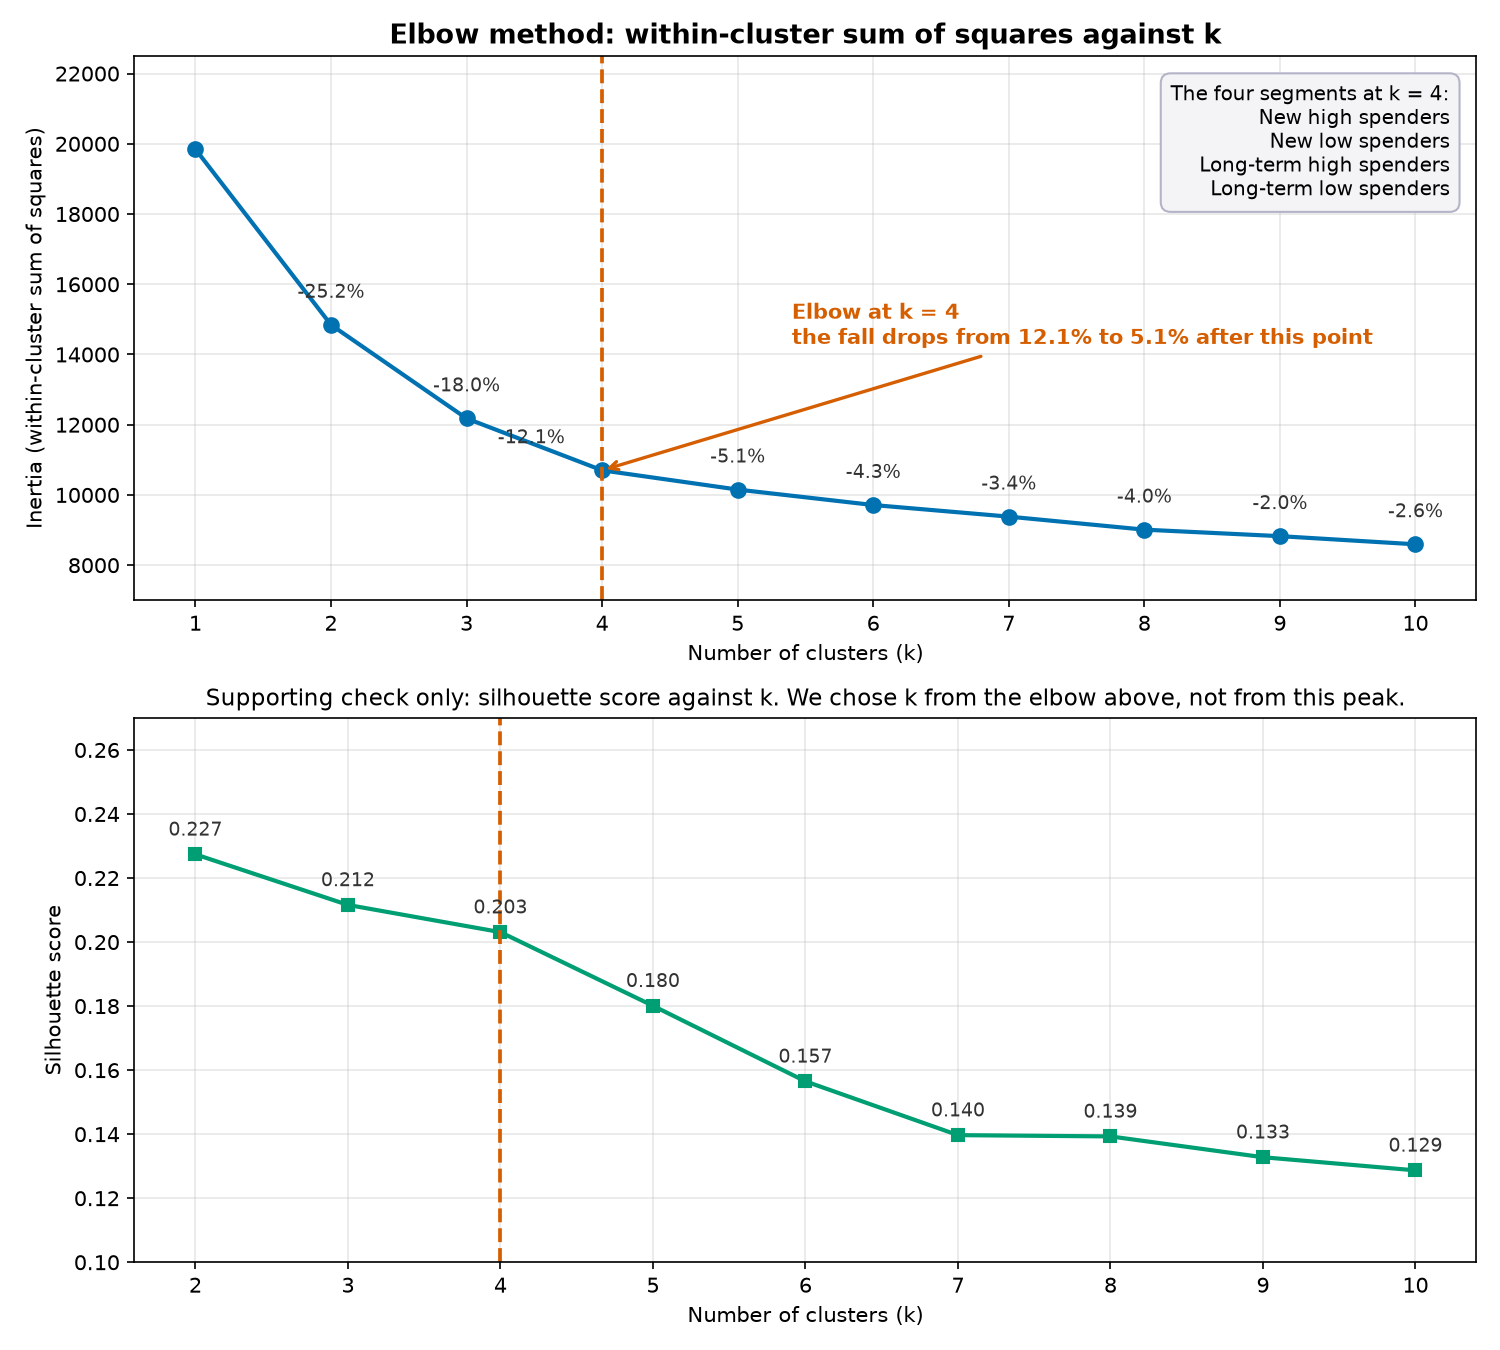

In [4]:
display(Image(filename=str(PLOTS / "elbow_method.png"), width=880))

We chose k = 4. Inertia falls 25.2% at k = 2, 18.0% at k = 3 and 12.1% at k = 4, then
only 5.1% at k = 5 and less after that. The drop from 12.1% to 5.1% is the sharpest
change in the sequence, so k = 4 is the last cluster that buys a large improvement.

The silhouette score is a supporting check, not the rule. It is highest at k = 2, at
0.2274, and falls to 0.2031 at k = 4. We did not follow that peak. The assignment asks
for the elbow method, and two clusters would split the base into little more than newer
and longer standing customers, which gives the business one group to contact and one to
leave alone. At k = 4 the churn rates run from 4.8% to 48.7%, which is a difference the
business can act on.

## 3. The cluster profiles

Every name comes from code, not from a person reading the table. The pipeline converts
each cluster centre back into months and dollars with the saved scaler, then compares it
with the training means of 32.36 months and $64.54. Tenure below the mean gives "New" and
above gives "Long-term". A monthly charge below the mean gives "low spenders" and above
gives "high spenders". The pipeline stops if two clusters end up with the same name.

The table is sorted by churn rate, highest first, so the first row is the first retention
target. Cluster ID numbers can move between runs, so every document refers to the names.

In [5]:
profile[["cluster", "segment", "size", "share_pct", "churners", "churn_rate",
         "test_size", "test_churn_rate", "tenure_months", "monthly_charges"]]

,cluster,segment,size,share_pct,churners,churn_rate,test_size,test_churn_rate,tenure_months,monthly_charges
0,0,New high spenders,1775,31.51,864,0.4868,449,0.5056,14.9,81.1
1,3,New low spenders,1381,24.51,342,0.2476,345,0.2290,10.5,32.1
2,2,Long-term high spenders,1512,26.84,243,0.1607,402,0.1418,58.7,93.8
3,1,Long-term low spenders,966,17.15,46,0.0476,213,0.0516,54.5,34.8


In [6]:
profile[["segment", "gender_male", "senior_citizen", "dependents", "phone_service",
         "multiple_lines", "fiber_optic", "contract_one_year", "contract_two_year"]]

,segment,gender_male,senior_citizen,dependents,phone_service,multiple_lines,fiber_optic,contract_one_year,contract_two_year
0,New high spenders,0.4992,0.2372,0.1803,0.9977,0.4130,0.4163,0.1938,0.2496
1,New low spenders,0.5351,0.0652,0.2998,0.7951,0.4098,0.4345,0.2209,0.2390
2,Long-term high spenders,0.5060,0.2249,0.3313,0.9967,0.4325,0.4537,0.2044,0.2388
3,Long-term low spenders,0.4959,0.0745,0.4586,0.7288,0.4161,0.4451,0.2246,0.2391


## 4. The cluster charts

Each chart names the segments in plain English, because the rubric asks for the clusters
to be visualised and labelled. Every segment keeps one colour across all five charts, from
a colour-blind safe palette.

The scatter below plots every training customer in the units the business uses, months and
dollars. The four centres are marked with an X and labelled. The split is clean because
these are the two columns K-Means grouped on.

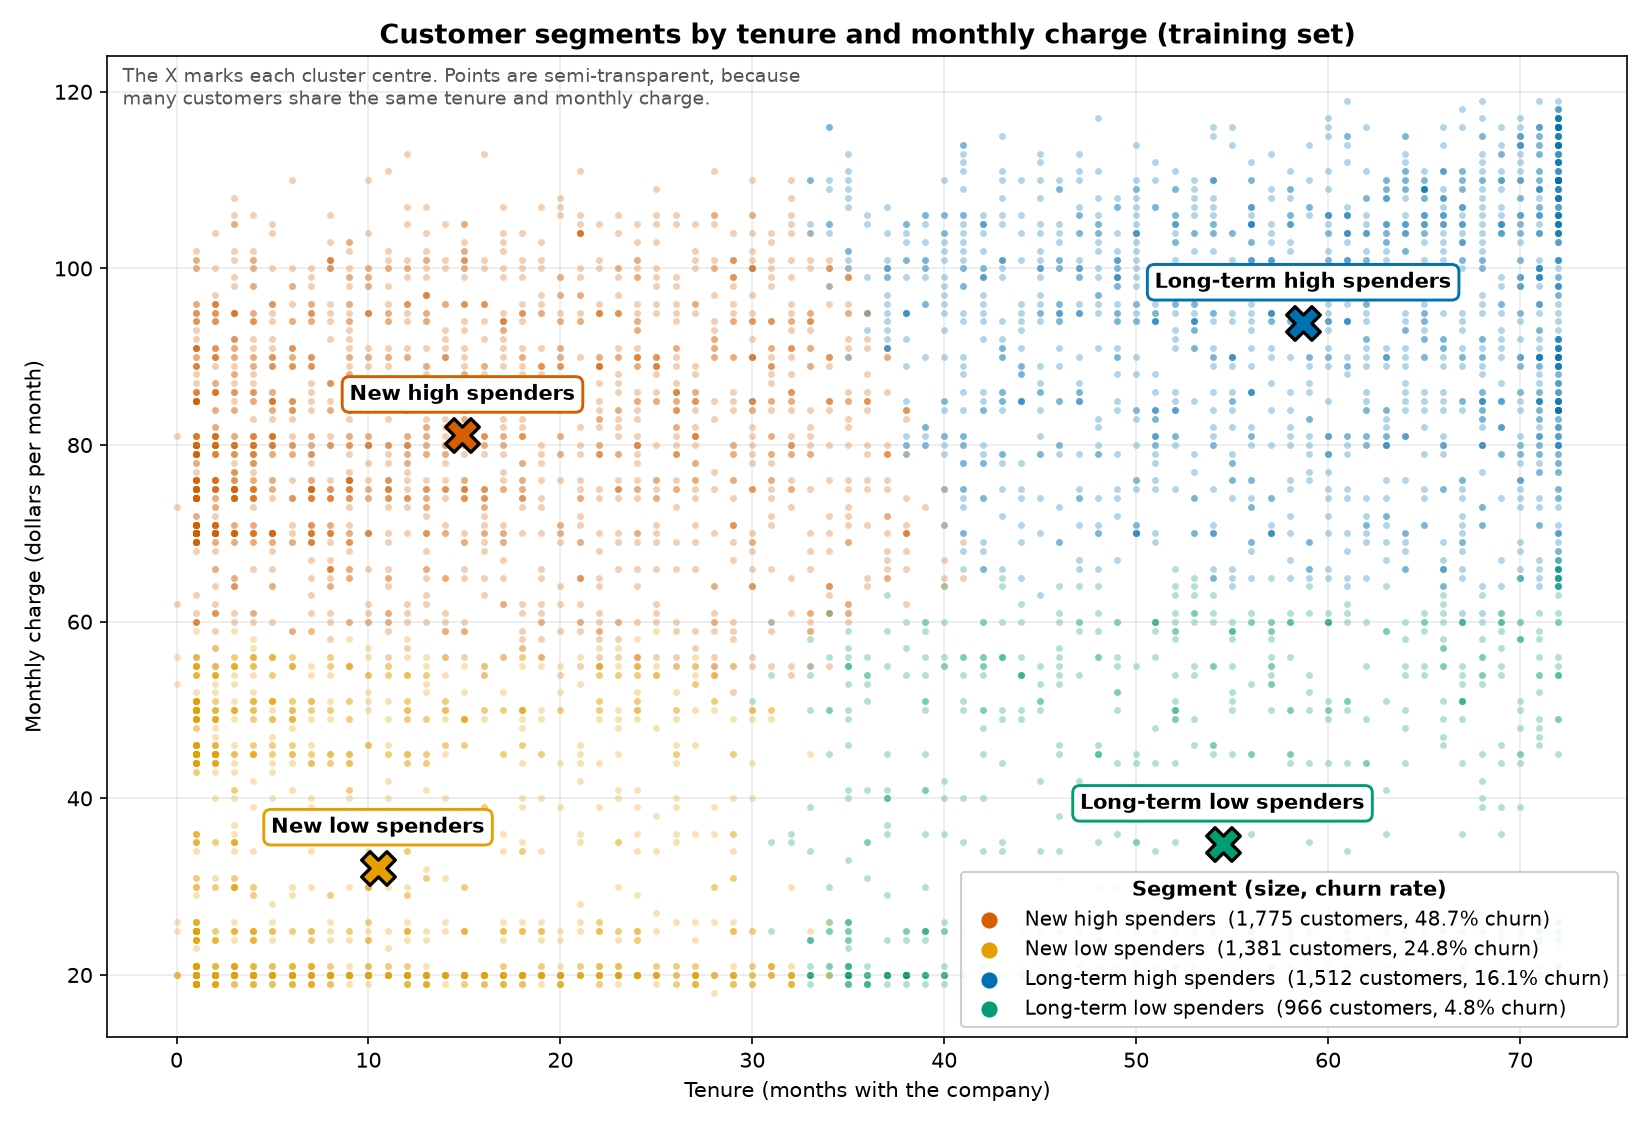

In [7]:
display(Image(filename=str(PLOTS / "segments_tenure_vs_charges.png"), width=920))

The next chart projects all 10 features into two dimensions with PCA, which is used for
this picture only. The model itself clusters on all 10 features. The two components hold
57.6% of the variance, so the picture is a summary rather than the whole story.

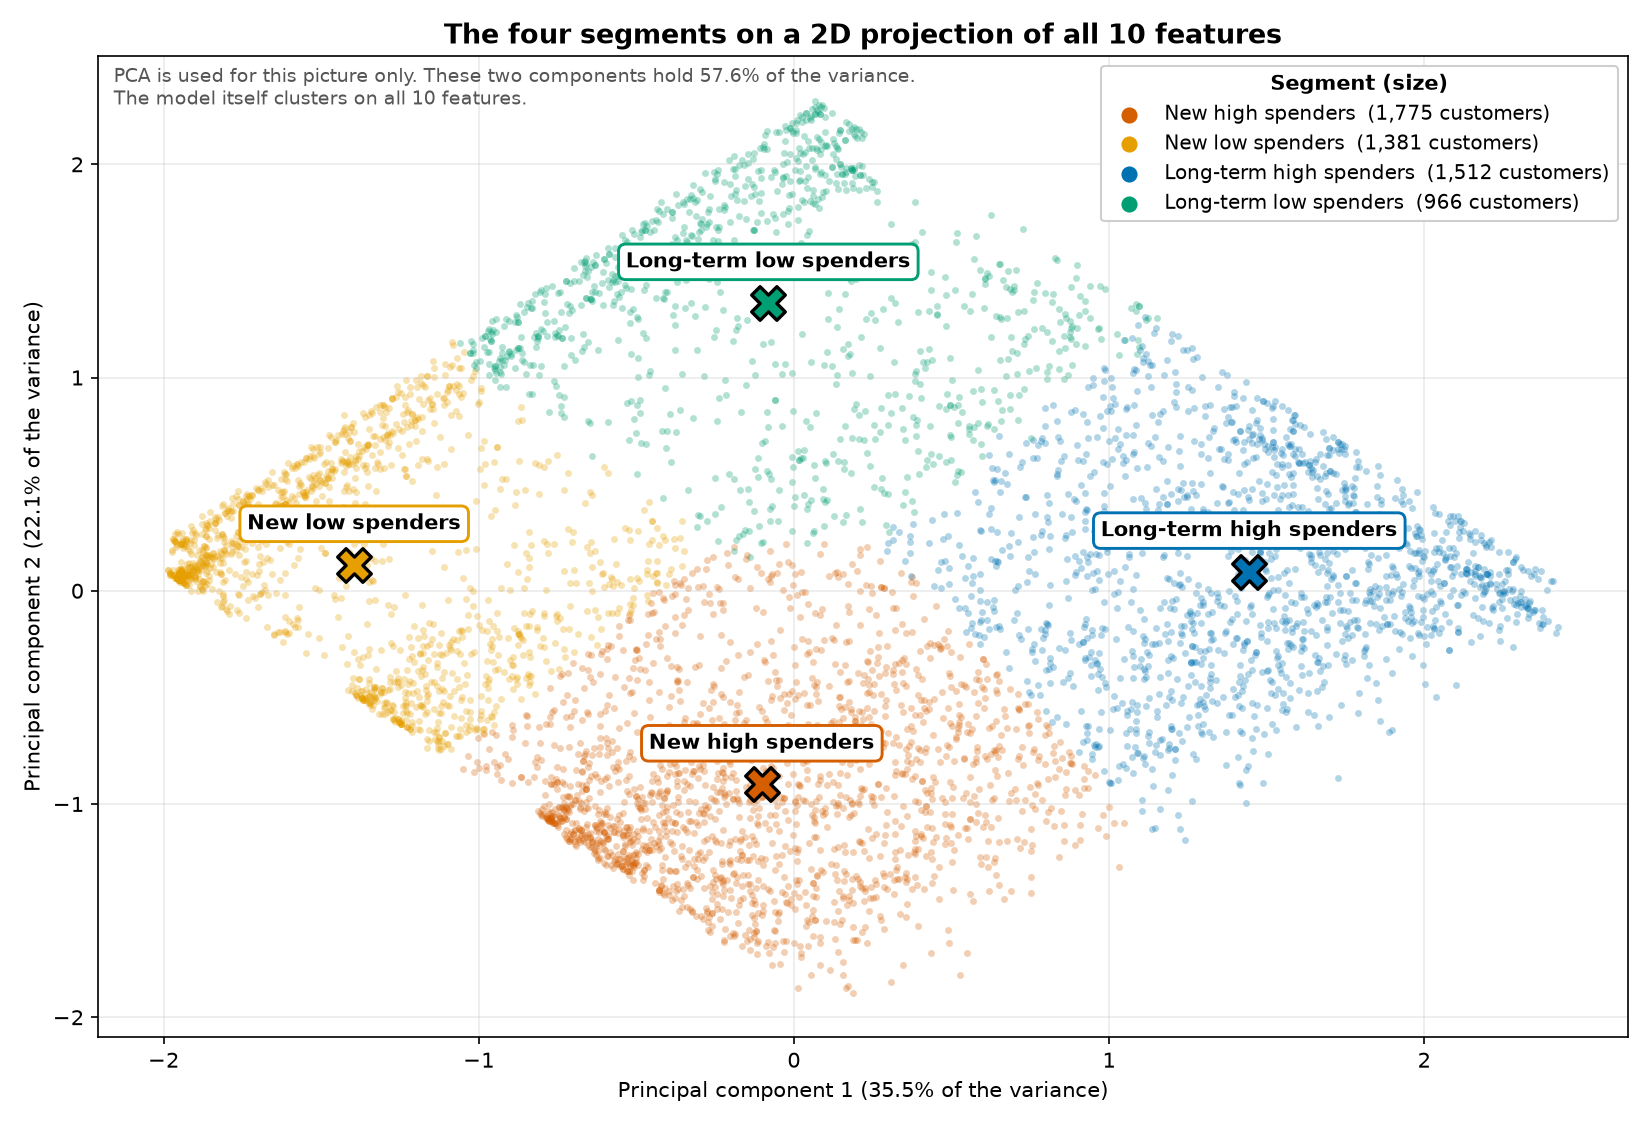

In [8]:
display(Image(filename=str(PLOTS / "segments_pca.png"), width=920))

The bar chart compares each segment with the 26.54% overall churn rate, shown as the
dashed line. Two segments sit above it and two below.

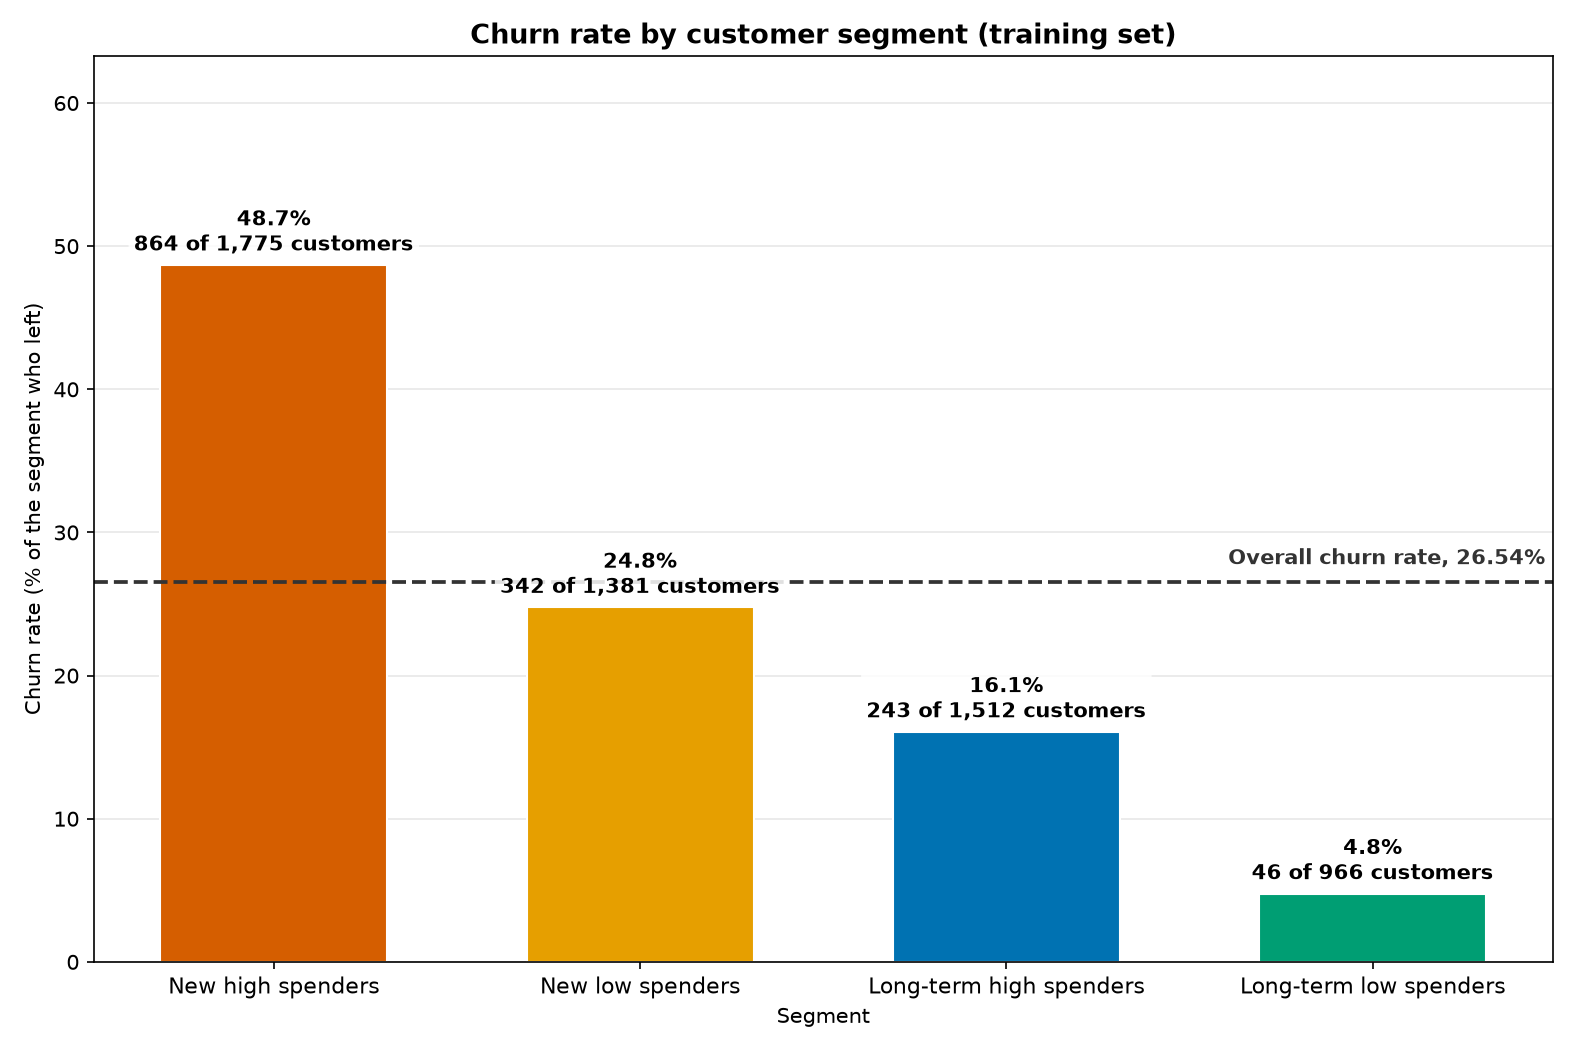

In [9]:
display(Image(filename=str(PLOTS / "churn_rate_by_segment.png"), width=880))

The heatmap shows the profile table with the real values in each cell. Each column is
shaded against the other segments. Tenure and monthly charge separate the segments
clearly. Contract type and internet type barely move between them, which the limitations
section of the PDF explains.

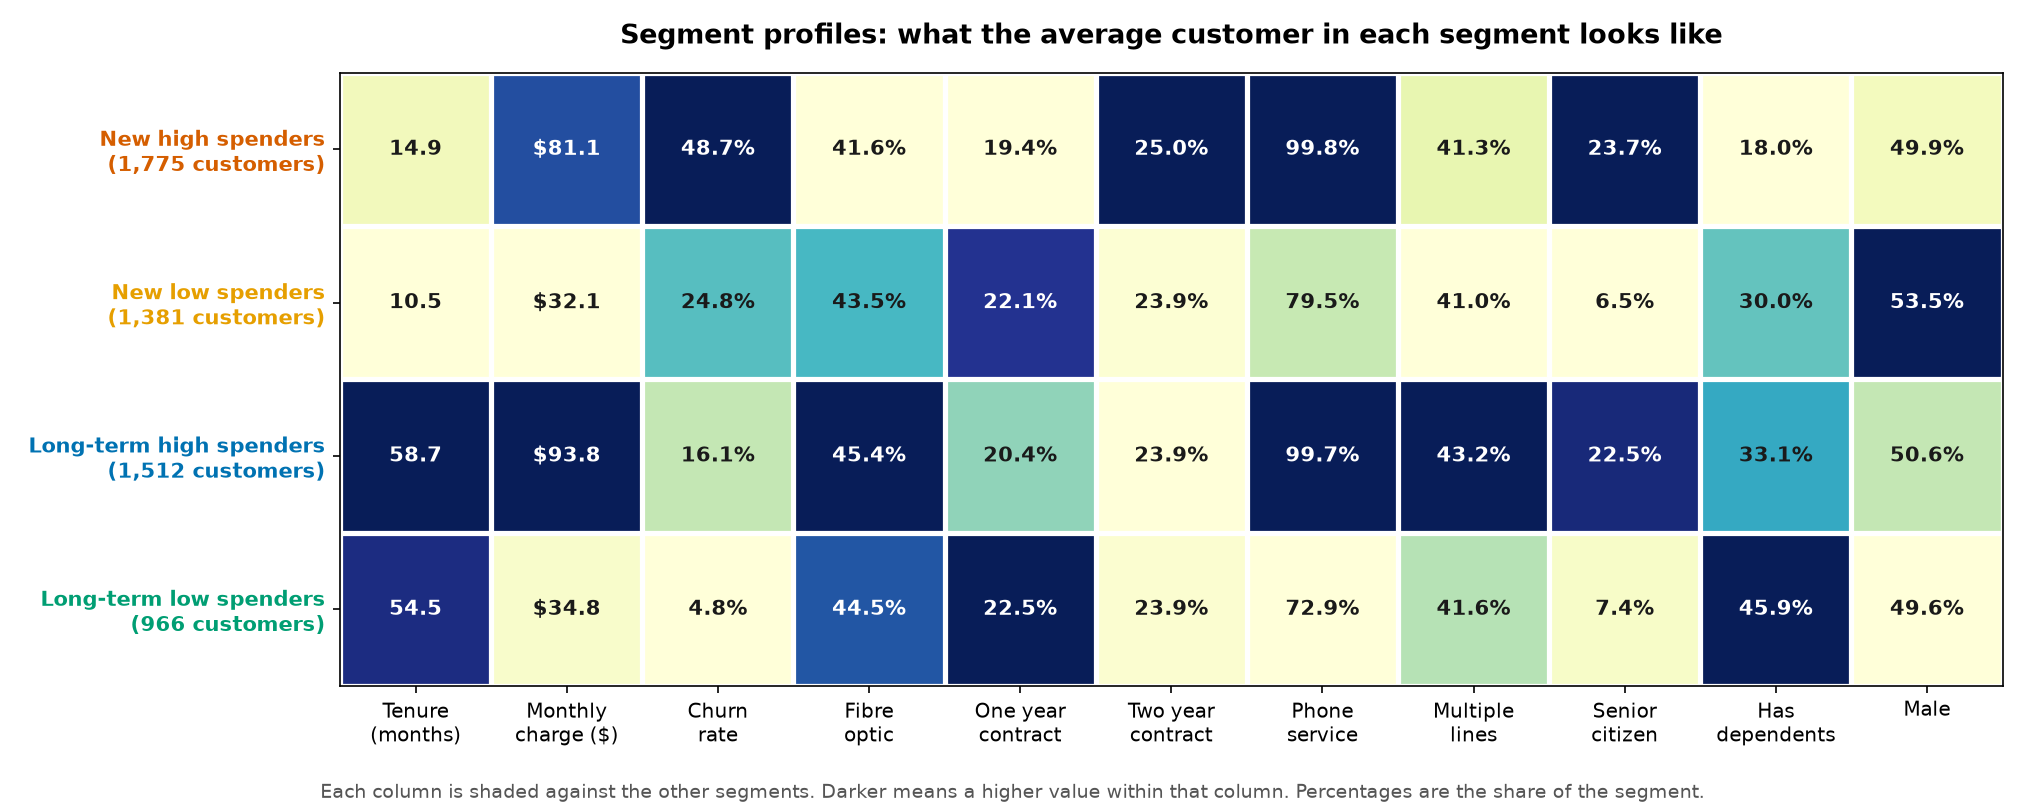

In [10]:
display(Image(filename=str(PLOTS / "segment_profiles.png"), width=1000))

## 5. The segments and what to do about them

The text below is read from `build_docs.py`, the same source the README uses, so the
notebook and the README cannot disagree. Segments are listed with the highest churn rate
first, which is also the order of the retention work.

In [11]:
from build_docs import load_json, segment_story, SUMMARY_PATH

summary = load_json(SUMMARY_PATH)

for seg in summary["segments"]:
    story, actions = segment_story(seg, summary)
    print("=" * 78)
    print(seg["segment"].upper())
    print("=" * 78)
    print(story)
    print()
    for n, action in enumerate(actions, start=1):
        print(f"  {n}. {action}")
    print()

NEW HIGH SPENDERS
This segment holds 1,775 of the 5,634 training customers, 31.5% of the base. 864 of them left, a churn rate of 48.7%, against 26.54% across all customers. The average customer here has been with the company 14.9 months and pays $81.10 a month. 55.7% are on a month to month plan. In the held out test set the same segment holds 449 customers and churns at 50.6%. Two numbers in the profile line up with the churn rate. These customers are well below the 32.4 month average tenure and well above the $64.54 average bill, so they pay a lot early. Nothing holds them either, because more than half have no fixed term and can leave at the end of any month. The segment also carries the largest share of senior citizens, 23.7%.

  1. Put the retention budget here first. This segment produced 864 of the 1,495 churners in the training data, more than the other three segments added together.
  2. Offer a fixed term plan to the 55.7% on month to month, priced at or below the $81.10 they

Size multiplied by churn rate gives the number of churners a segment produces, which is
the order to work through. New high spenders come first on both counts. They are the
largest segment and the one with the highest churn rate.

In [12]:
priority = profile[["segment", "size", "churn_rate", "churners", "monthly_charges"]].copy()
priority["monthly_billing_at_risk"] = (priority["churners"] * priority["monthly_charges"]).round(0)
priority.insert(0, "priority", range(1, len(priority) + 1))
priority

,priority,segment,size,churn_rate,churners,monthly_charges,monthly_billing_at_risk
0,1,New high spenders,1775,0.4868,864,81.1,70070.0
1,2,New low spenders,1381,0.2476,342,32.1,10978.0
2,3,Long-term high spenders,1512,0.1607,243,93.8,22793.0
3,4,Long-term low spenders,966,0.0476,46,34.8,1601.0


## 6. Deliverables written

The run above writes every file listed below. [`build_docs.py`](build_docs.py) generates
`README.md` and `elbow_method_results.pdf` from `clustering_summary.json`, so nobody types
the numbers by hand:

```bash
python Clustering_Analysis/build_docs.py
```

In [13]:
for name in ["clustering_analysis.py", "build_docs.py", "kmeans_model.pkl",
             "cluster_selection_metrics.csv", "cluster_profiles.csv",
             "cluster_assignments.csv", "clustering_summary.json",
             "elbow_method_results.pdf", "README.md",
             "cluster_visualisations/elbow_method.png",
             "cluster_visualisations/segments_tenure_vs_charges.png",
             "cluster_visualisations/segments_pca.png",
             "cluster_visualisations/churn_rate_by_segment.png",
             "cluster_visualisations/segment_profiles.png"]:
    path = OUT_DIR / name
    size = f"{path.stat().st_size / 1024:,.1f} KB" if path.exists() else "MISSING"
    print(f"{name:<52} {size}")

clustering_analysis.py                               28.2 KB
build_docs.py                                        33.3 KB
kmeans_model.pkl                                     23.4 KB
cluster_selection_metrics.csv                        0.3 KB
cluster_profiles.csv                                 0.7 KB
cluster_assignments.csv                              231.9 KB
clustering_summary.json                              4.4 KB
elbow_method_results.pdf                             201.2 KB
README.md                                            12.6 KB
cluster_visualisations/elbow_method.png              159.7 KB
cluster_visualisations/segments_tenure_vs_charges.png 206.8 KB
cluster_visualisations/segments_pca.png              298.2 KB
cluster_visualisations/churn_rate_by_segment.png     68.9 KB
cluster_visualisations/segment_profiles.png          148.4 KB
